In [1]:
import numpy as np
from matplotlib import pyplot as plt
from astropy import units as u
from astropy import constants as c
from scipy.integrate import quad

In [2]:
# Physical constants

e_charge = 1.602e-19  # C
mu_air = 1.00000037*c.mu0.value
muon_mass = (105.65837 * u.MeV/c.c**2).to(u.kg).value  # kg
muon_lifetime = 2.19698e-6  # s

blue_UV = 380e-9  # m
UVB_UVC = 280e-9  # m
# UV_limit = 250e-9  # m

P_std = 101325  # Pa
T_15C = 288.15  # K

atmos_height = 112.8e3  # m
# atmos_height = 11e3  # m  # relevant height

# dry_adiab_lapse_rate = 9.76e-3  # K / m
# molar_mass_dry_air = 0.02896968  # kg/mol

In [3]:
# VERITAS constants

PMT_min = 185e-9  # m
PMT_max = 650e-9  # m
# constant_efficiency_factor = 0.88 * 0.97

# D = 12  # m

veritas_alt = 1268  # m

In [4]:
# This is to provide some weak dependence of n on lambda.
# This has a modest but appreciable impact in the Frank-Tamm equation due to the factor (1 - 1 / (beta * n))**2)
# Still regard lambda as being photon wavelength in vacuum; lambda = c / nu

def n_air(lam, alt=veritas_alt):

    # Empirically determined constants
    A = 2.73e-4 
    B = 1.23e-18  # m^2
    C = 3.56e-32  # m^4
    
    # Scale height of the atmosphere
    h_0 = 8.4e3  # m

    epsilon_0 = A + B/lam**2 + C/lam**4
    epsilon = epsilon_0 * np.exp(-alt / h_0)
    
    return 1 + epsilon

In [5]:
def d2Ndxdlam(lam, beta, q=e_charge, mu=mu_air):

    return np.pi * q**2 * mu / c.h.value * (c.c.value / lam**2) * (1 - 1 / (beta * n_air(lam))**2)

In [6]:
def dNdx(lam_low, lam_high, beta, q=e_charge, mu=mu_air):

    return quad(d2Ndxdlam, lam_low, lam_high, args=(beta, q, mu))[0]

In [7]:
def get_beta(E, m=c.m_e.value):

    return np.sqrt(1 - m**2 * c.c.value**4 / E**2)

In [8]:
def get_gamma(E, m=c.m_e.value):

    return E / (m * c.c.value**2)

In [9]:
def decay_prob(t, lifetime):

    return 1 - np.exp(-t / lifetime)

In [10]:
def decay_prob_dens(t, lifetime):

    return np.exp(-t / lifetime) / lifetime

In [11]:
def get_cherenkov_angle(beta, n):

    return np.arccos(1 / (beta * n))

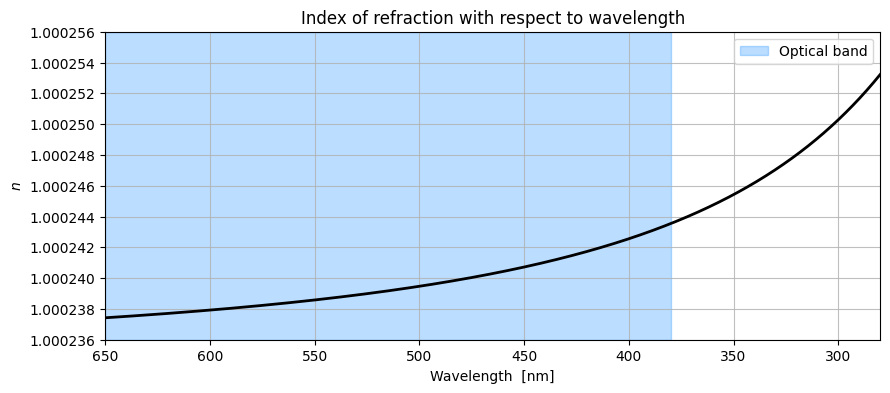

In [12]:
lams = np.linspace(UVB_UVC, PMT_max, 10000)

fig, ax = plt.subplots(figsize=(10, 4))

plt.plot(lams, n_air(lams), c='black', lw=2)
plt.axvspan(blue_UV, PMT_max, color='dodgerblue', alpha=0.3, label='Optical band')

plt.grid(alpha=0.8)
plt.xlabel('Wavelength  [nm]')
plt.ylabel(r'$n$')
plt.title('Index of refraction with respect to wavelength')

xticks = ax.xaxis.axes.get_xticks()
xticks_nm = [int(round(tick * 1e9)) for tick in xticks]
plt.xticks(ticks=xticks, labels=xticks_nm)

yticks = ax.yaxis.axes.get_yticks()
yticks_str = [f'%.6f' % tick for tick in yticks]
plt.yticks(ticks=yticks, labels=yticks_str)

# plt.xlim(PMT_min, PMT_max)
plt.xlim(PMT_max, UVB_UVC)

plt.legend()
plt.show()

In [13]:
reference_n = n_air(blue_UV)
max_n = n_air(UVB_UVC)

In [14]:
# Minimum muon energy (in GeV) to emit Cherenkov radiation in air

min_muon_gamma = (1 - max_n**-2) ** -0.5
min_muon_E = min_muon_gamma * muon_mass * c.c.value**2 * u.J.to(u.GeV)
min_muon_E

4.695933084286152

In [15]:
# Make arrays of muon energies

muon_E_span = np.logspace(np.log10(min_muon_E), np.log10(150e3), 10000)  # GeV
muon_energies = np.array([5, 10, 50, 100, 500, 1e3, 10e3, 100e3])  # GeV

In [16]:
# Time and distance arrays

times = np.linspace(0, 7e3 * muon_lifetime, 10000)
dists = np.linspace(0, atmos_height, 10000)

In [17]:
clrs = ['firebrick', 'darkorange', 'gold', 'lime', 'forestgreen', 'dodgerblue', 'blueviolet', 'fuchsia']

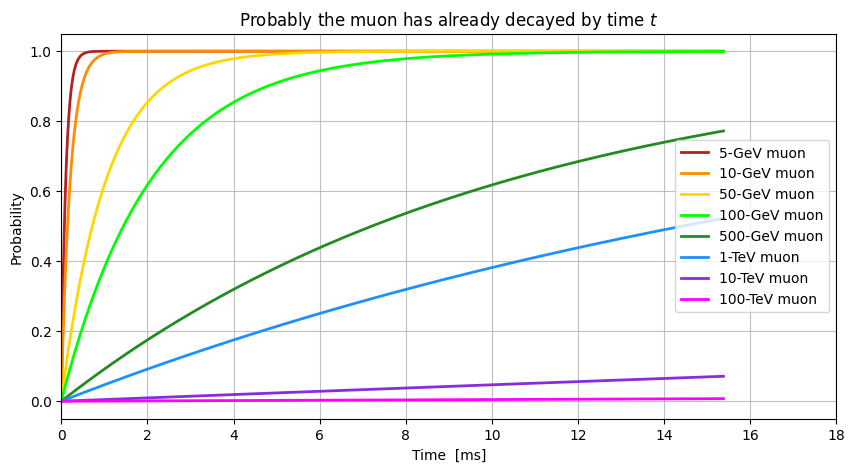

In [18]:
fig, ax = plt.subplots(figsize=(10, 5))

for i, E in enumerate(muon_energies):
    gamma = get_gamma(E=E * u.GeV.to(u.J), m=muon_mass)
    if E < 1e3:
        label = str(int(E)) + '-GeV muon'
    else:
        label = str(int(E/1e3)) + '-TeV muon'
    plt.plot(times, decay_prob(times, gamma * muon_lifetime), c=clrs[i], lw=2, label=label)

plt.grid(alpha=0.8)
plt.xlabel('Time  [ms]')
plt.ylabel('Probability')
plt.title(r'Probably the muon has already decayed by time $t$')

ticks = ax.xaxis.axes.get_xticks()
ticks_ms = [str(int(tick * 1e3)) for tick in ticks]
plt.xticks(ticks=ticks, labels=ticks_ms)

plt.xlim(xmin=0)

plt.legend()
plt.show()

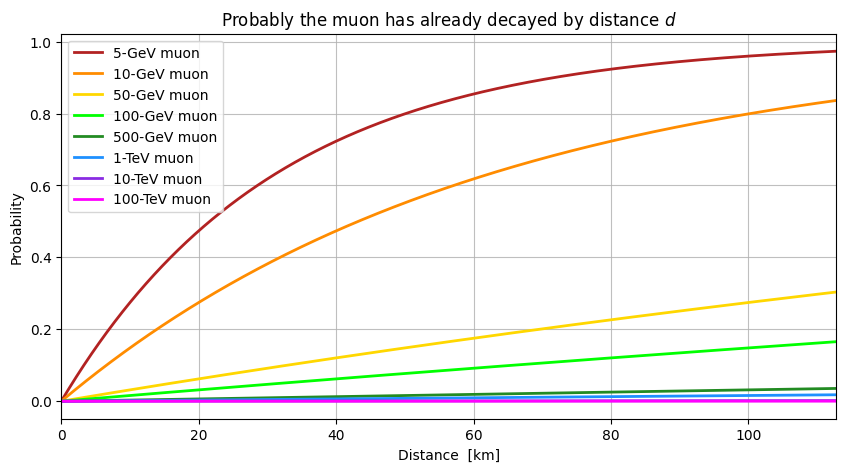

In [19]:
fig, ax = plt.subplots(figsize=(10, 5))

# beta = 0.1
# plt.plot(dists, decay_prob(dists / (c.c.value * beta), (1-0.1**2)**-0.5 * muon_lifetime), c='black', ls='--', lw=2, 
#          label='Muon travelling at 10% the speed of light')

for i, E in enumerate(muon_energies):
    
    gamma = get_gamma(E=E * u.GeV.to(u.J), m=muon_mass)
    beta = get_beta(E=E * u.GeV.to(u.J), m=muon_mass)
    
    if E < 1e3:
        label = str(int(E)) + '-GeV muon'
    else:
        label = str(int(E/1e3)) + '-TeV muon'
        
    plt.plot(dists, decay_prob(dists / (c.c.value * beta), gamma * muon_lifetime), c=clrs[i], lw=2, label=label)

plt.grid(alpha=0.8)
plt.xlabel('Distance  [km]')
plt.ylabel('Probability')
plt.title(r'Probably the muon has already decayed by distance $d$')

ticks = ax.xaxis.axes.get_xticks()
ticks_km = [str(int(tick * 1e-3)) for tick in ticks]
plt.xticks(ticks=ticks, labels=ticks_km)

plt.xlim(0, atmos_height)

plt.legend()
plt.show()

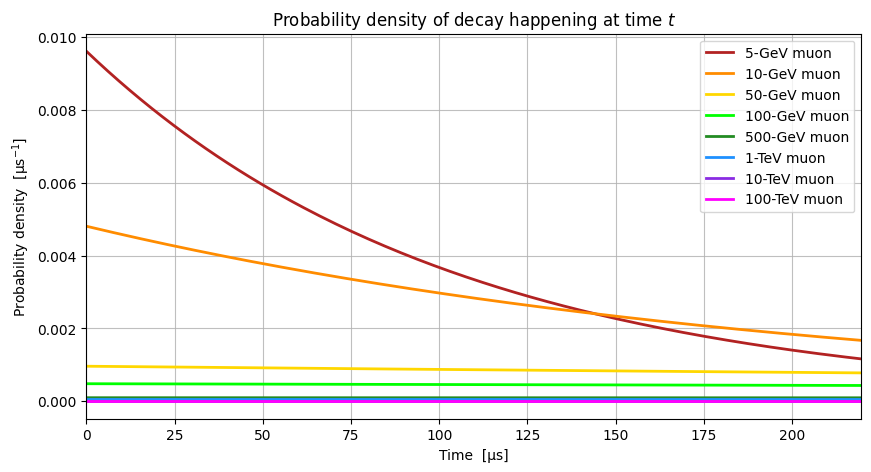

In [20]:
fig, ax = plt.subplots(figsize=(10, 5))

for i, E in enumerate(muon_energies):
    gamma = get_gamma(E=E * u.GeV.to(u.J), m=muon_mass)
    if E < 1e3:
        label = str(int(E)) + '-GeV muon'
    else:
        label = str(int(E/1e3)) + '-TeV muon'
    plt.plot(times * 1e6, decay_prob_dens(times * 1e6, gamma * muon_lifetime * 1e6), c=clrs[i], lw=2, label=label)

plt.grid(alpha=0.8)
plt.xlabel('Time  [µs]')
plt.ylabel(r'Probability density  [µs$^{-1}$]')
plt.title(r'Probability density of decay happening at time $t$')

plt.xlim(0, 100 * muon_lifetime * 1e6)

plt.legend()
plt.show()

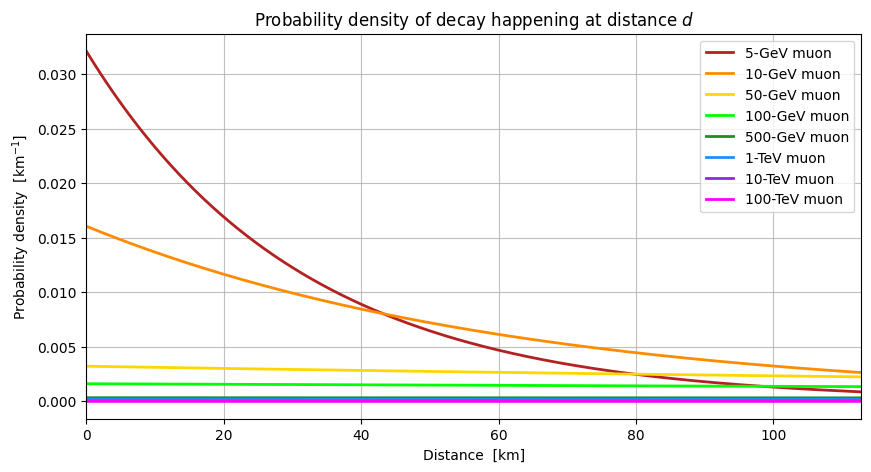

In [21]:
fig, ax = plt.subplots(figsize=(10, 5))

for i, E in enumerate(muon_energies):
    gamma = get_gamma(E=E * u.GeV.to(u.J), m=muon_mass)
    if E < 1e3:
        label = str(int(E)) + '-GeV muon'
    else:
        label = str(int(E/1e3)) + '-TeV muon'
    plt.plot(dists * 1e-3, decay_prob_dens(dists * 1e-3, gamma * muon_lifetime * c.c.value * beta * 1e-3), 
             c=clrs[i], lw=2, label=label)

plt.grid(alpha=0.8)
plt.xlabel('Distance  [km]')
plt.ylabel(r'Probability density  [km$^{-1}$]')
plt.title(r'Probability density of decay happening at distance $d$')

plt.xlim(0, atmos_height * 1e-3)

plt.legend()
plt.show()

In [33]:
# Calculate Cherenkov angles = muon ring radius (angular size)

betas = get_beta(E=muon_E_span * u.GeV.to(u.J), m=muon_mass)

angles = np.zeros_like(betas)
for i, beta in enumerate(betas):
    if beta > 1 / reference_n:
        angles[i] = get_cherenkov_angle(beta, reference_n)
    else:
        angles[i] = np.nan
        
angles_deg = angles / np.pi * 180

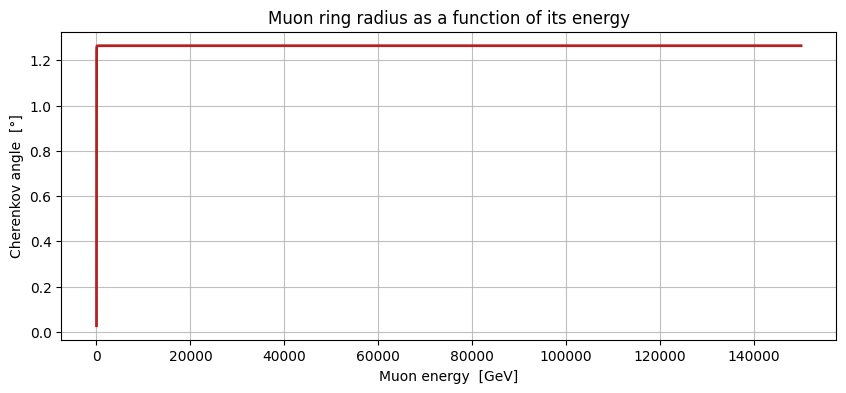

In [34]:
fig, ax = plt.subplots(figsize=(10, 4))

plt.plot(muon_E_span, angles_deg, c='firebrick', lw=2)

plt.grid(alpha=0.8)
plt.xlabel('Muon energy  [GeV]')
plt.ylabel('Cherenkov angle  [°]')
plt.title('Muon ring radius as a function of its energy')

plt.show()

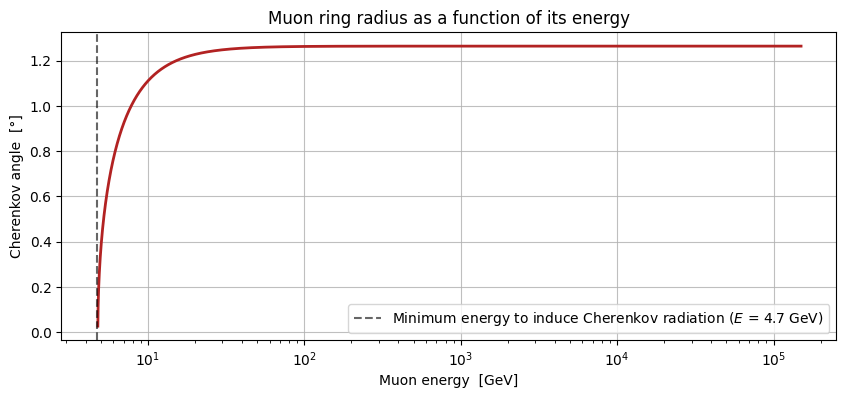

In [35]:
fig, ax = plt.subplots(figsize=(10, 4))

plt.plot(muon_E_span, angles_deg, c='firebrick', lw=2)
plt.axvline(x=min_muon_E, color='black', ls='--', lw=1.5, alpha=0.6,
            label=r'Minimum energy to induce Cherenkov radiation ($E$ = {} GeV)'.format(round(min_muon_E, 2)))

plt.grid(alpha=0.8)
plt.xlabel('Muon energy  [GeV]')
plt.ylabel('Cherenkov angle  [°]')
plt.title('Muon ring radius as a function of its energy')

plt.xscale('log')

plt.legend()
plt.show()

In [36]:
# Note that, where Cherenkov angle is rapidly changing (low energies),
# angle might be modestly increasing with Cherenkov photon wavelength
# due to the weak dependence of n on wavelength.

In [37]:
# Calculate Cherenkov angles for specific muon energies

some_betas = get_beta(E=muon_energies * u.GeV.to(u.J), m=muon_mass)
some_angles = get_cherenkov_angle(some_betas, reference_n)
some_angles_deg = some_angles / np.pi * 180

In [38]:
print('Muon ring radii:')
for i, E in enumerate(muon_energies):
    if E < 1e3:
        text = str(int(E)) + '-GeV muon:'
    else:
        text = str(int(E/1e3)) + '-TeV muon:'
    print(text, str(round(some_angles_deg[i], 4)) + '°')

Muon ring radii:
5-GeV muon: 0.3641°
10-GeV muon: 1.1101°
50-GeV muon: 1.2586°
100-GeV muon: 1.2629°
500-GeV muon: 1.2643°
1-TeV muon: 1.2644°
10-TeV muon: 1.2644°
100-TeV muon: 1.2644°


In [39]:
# Adapted limits of integration

wavelengths = np.linspace(PMT_max, UVB_UVC, 1000)
ring_intensities = np.zeros_like(betas)

for i, beta in enumerate(betas):

    okay = True
    j = 0
    max_wavelength = wavelengths[j]
    
    while okay and not beta > 1 / n_air(max_wavelength):
        j += 1
        try:
            max_wavelength = wavelengths[j]
        except:
            okay = False
        
    if okay:
        ring_intensities[i] = dNdx(lam_low=UVB_UVC, lam_high=max_wavelength, beta=beta)
    else:
        ring_intensities[i] = 0  # No Cherenkov photons in the range of PMT sensitivity

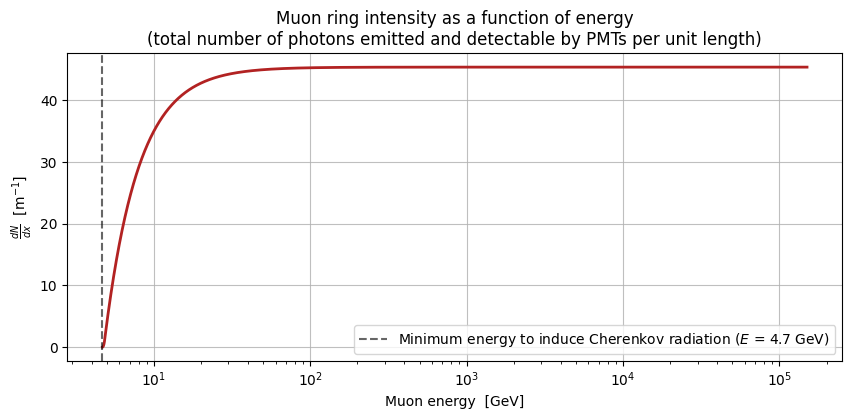

In [40]:
fig, ax = plt.subplots(figsize=(10, 4))

plt.plot(muon_E_span, ring_intensities, c='firebrick', lw=2)
plt.axvline(x=min_muon_E, color='black', ls='--', lw=1.5, alpha=0.6,
            label=r'Minimum energy to induce Cherenkov radiation ($E$ = {} GeV)'.format(round(min_muon_E, 2)))

plt.grid(alpha=0.8)
plt.xlabel('Muon energy  [GeV]')
plt.ylabel(r'$\frac{dN}{dx}$  [m$^{-1}$]')
plt.title('Muon ring intensity as a function of energy' 
          + '\n(total number of photons emitted and detectable by PMTs per unit length)')

plt.xscale('log')

plt.legend()
plt.show()

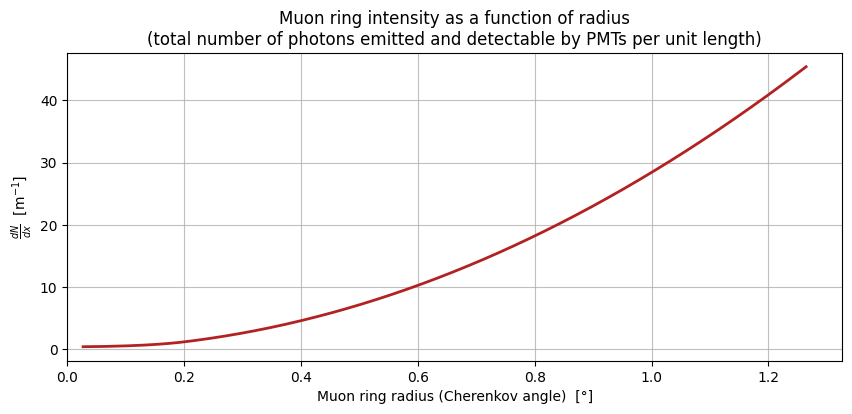

In [41]:
fig, ax = plt.subplots(figsize=(10, 4))

plt.plot(angles_deg, ring_intensities, c='firebrick', lw=2)

plt.grid(alpha=0.8)
plt.xlabel('Muon ring radius (Cherenkov angle)  [°]')
plt.ylabel(r'$\frac{dN}{dx}$  [m$^{-1}$]')
plt.title('Muon ring intensity as a function of radius' 
          + '\n(total number of photons emitted and detectable by PMTs per unit length)')

plt.xlim(xmin=0)

plt.show()